# Vehicule dataset


In [1]:
## Importing
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
from evclust.utils import plotting, display_results_fuzzy_partition, display_results_evidential
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from evclust.datasets import load_vehicule

from evclust.ecm import ecm
from evclust.wecm_new_barycenter import wecm
from evclust.wecm_new_barycenter_2 import wecm as wecm2
from evclust.gwecm import gwecm
from evclust.fcm.fcm_keller2000 import fcm as fcm_keller2000
from evclust.fcm.fcm_wang2004 import fcm as fcm_wang2004
from evclust.fcm.fcm_frigui2004 import scad1
from evclust.fcm.fcm_frigui2004 import scad2
from evclust.fcm.ifwfcm_xing2014 import fcm as ifwfcm_xing2014
from evclust.fcm.ifwfcm_kd_xing2014 import fcm as ifwfcm_kd_xing2014

Instances 845 - Features 18 - Class 4
    95  48   83  178   72  10  162  42  20  159  176  379  184   70   6  16  \
0   91  41   84  141   57   9  149  45  19  143  170  330  158   72   9  14   
1  104  50  106  209   66  10  207  32  23  158  223  635  220   73  14   9   
2   93  41   82  159   63   9  144  46  19  143  160  309  127   63   6  10   
3   85  44   70  205  103  52  149  45  19  144  241  325  188  127   9  11   
4  107  57  106  172   50   6  255  26  28  169  280  957  264   85   5   9   

   187  197  
0  189  199  
1  188  196  
2  199  207  
3  180  183  
4  181  183  


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


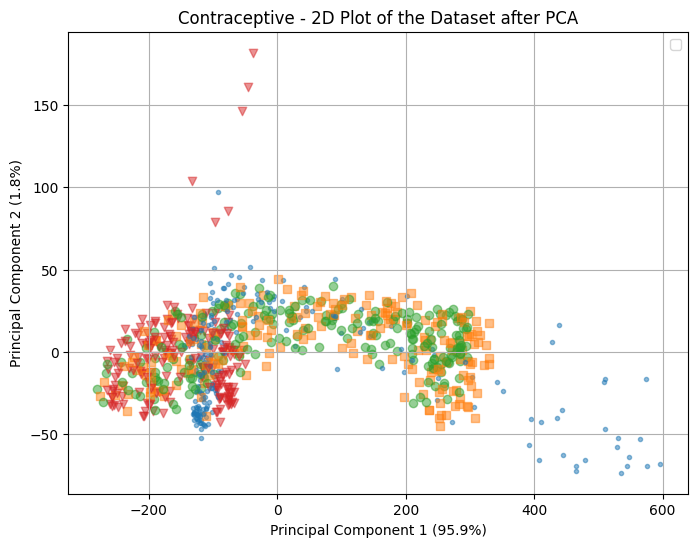

In [2]:

# fetch dataset
df = load_vehicule()
X = pd.DataFrame(df.iloc[:, :-1])
y = pd.DataFrame(df.iloc[:, -1])

label_column_nm = y.columns[0]
labels_encoder = LabelEncoder()
numeric_labels = labels_encoder.fit_transform(y[label_column_nm])
plotting(X, y, ds_name="Contraceptive", matrix_plot=False)
c = len(np.unique(numeric_labels))

# Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(scaler.fit_transform(X))

## Traditional ECM

In [3]:
%%capture
# Traditional ECM clustering
delta = np.sqrt(20)
ecm_models = np.array([])
for i in range(10):
    model = ecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", epsi=1e-5)
    ecm_models = np.append(ecm_models, model)

ecm_models = sorted(ecm_models, key=lambda x: x['crit'])

J values: [55.91935667876879, 55.91936021878914, 55.91936142282803, 55.91936184912518, 55.91956437872154, 55.91956553638296, 55.919566068496536, 55.91956628029463, 55.91956719621689, 55.91956851518663]
ARI values: [0.07851217316325952, 0.07851217316325952, 0.07851217316325952, 0.07851217316325952, 0.0789813273236167, 0.0789813273236167, 0.0789813273236167, 0.0789813273236167, 0.0789813273236167, 0.0789813273236167]
NS values: [1.7317084677932155, 1.7544767007336393, 1.7518276967777056, 1.7518260444462763, 1.7433960051246253, 1.7491273058489272, 1.7433969672404892, 1.7577335046592235, 1.7528730410621423, 1.7565704749448134]
NMI values: [0.10164057654892399, 0.10164057654892397, 0.10164057654892399, 0.10164057654892399, 0.10202579392355166, 0.10202579392355163, 0.10202579392355166, 0.10202579392355163, 0.10202579392355163, 0.10202579392355166]


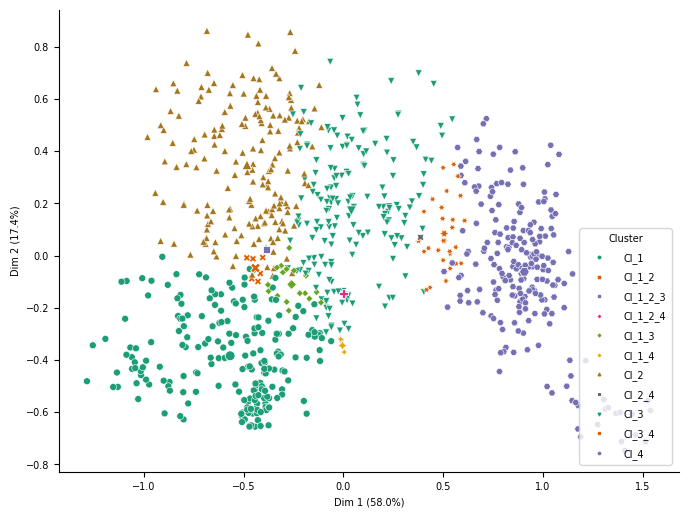

In [4]:
display_results_evidential(X, ecm_models, numeric_labels, up_low_appr=False)

## Weighted ECM (WECM)

In [ ]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(5):
    model = wecm(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None")
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.03010453241220773, 0.030735983354298918, 0.07150639180078008, 0.11556421220037265, 0.5378276828748985]
ARI values: [0.14161223973765133, 0.10033974314228976, 0.13414098763843021, 0.0937451190982004, 0.1599606687573108]
NS values: [1.6694836778906026, 1.4739210978812367, 1.499485066907624, 1.64132282603961, 4.302059071874617]
NMI values: [0.16691603839447886, 0.13988347321345984, 0.1803308073411284, 0.12216059459582083, 0.17205814595782584]


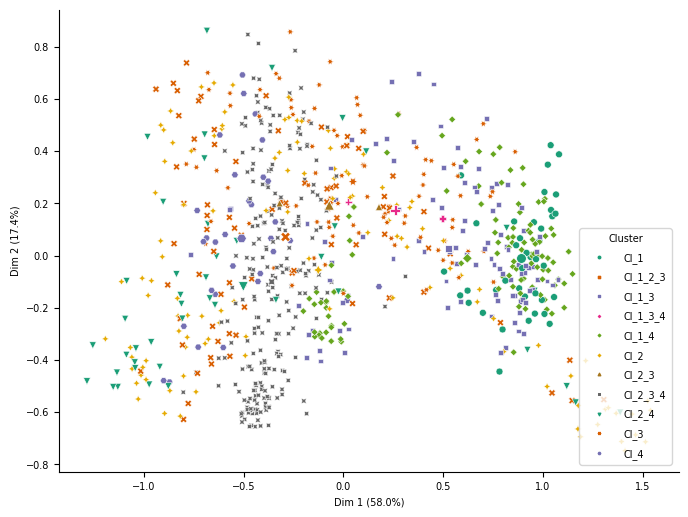

In [22]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

## WECM2

In [23]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(5):
    model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None", epsilon=1e-4)
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.18822896965414743, 0.18823446088549348, 0.23986866756312727, 0.24737963330403645, 0.25619800357971234]
ARI values: [0.1305528338190008, 0.13061408860459905, 0.11217986439178013, 0.11992369574426791, 0.11640500386971979]
NS values: [1.7338527299298097, 1.8120262072147266, 1.7399869321091184, 1.8339427737493341, 1.8056397717919759]
NMI values: [0.1800210587064142, 0.18013016031092097, 0.15115216577582036, 0.16805887715275353, 0.1644709118247202]


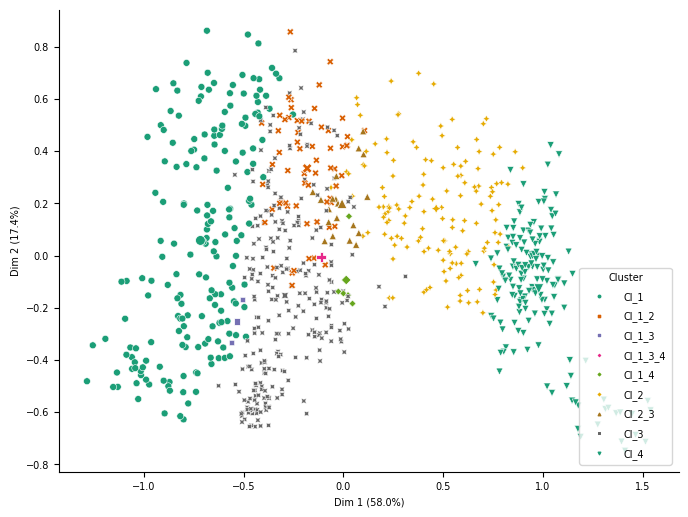

In [24]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

## Global weighted ECM - GWECM

In [3]:
%%capture
gwecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(5):
    model = gwecm(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None", epsilon=1e-4)
    gwecm_models = np.append(gwecm_models, model)

gwecm_models = sorted(gwecm_models, key=lambda model: model['crit'])

J values: [0.11419671054897383, 0.11419681689235067, 0.11419764100215099, 0.11420037043587046, 0.11845376320432713]
ARI values: [0.0916514361805669, 0.0916514361805669, 0.0916514361805669, 0.0916514361805669, 0.05944884224523919]
NS values: [1.5453231110709282, 1.4863534776721765, 1.5453564867992209, 1.5611520357256075, 1.7357282670513376]
NMI values: [0.15171894906861932, 0.15171894906861932, 0.15171894906861932, 0.15171894906861932, 0.09873369673591015]


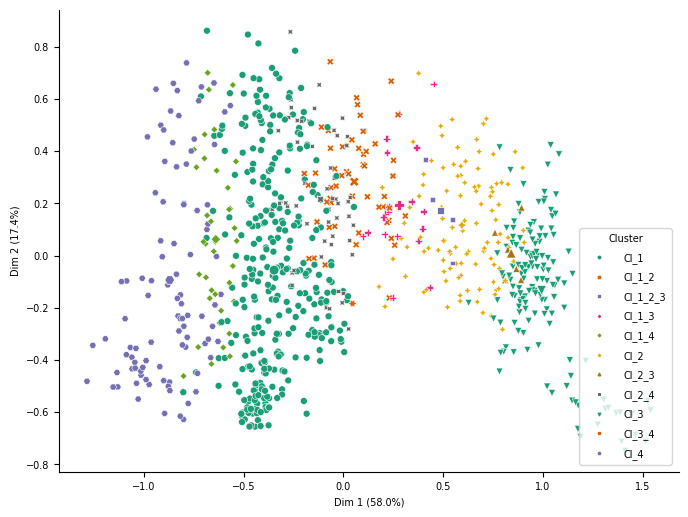

In [4]:
display_results_evidential(X, gwecm_models, numeric_labels, up_low_appr=False)

# Weighted FCM - Keller et al. 2000

In [25]:
%%capture
keller_models = np.array([])
w0 = np.ones((c, X.shape[1])) / X.shape[1]
for i in range(5):
    model = fcm_keller2000(X, c=c, w0=w0, verbose=True, epsilon=1e-6, init="None")
    keller_models = np.append(keller_models, model)
keller_models = sorted(keller_models, key=lambda model: model['obj_func'])

J values: [0.09287105878031726, 0.09287136222356432, 0.09287204931408785, 0.09287209886110195, 0.09287238453586785]
ARI values: [0.10803840476573981, 0.10803840476573981, 0.10803840476573981, 0.10927450597964415, 0.10927450597964415]
NMI values: [0.14386627856093803, 0.14386627856093803, 0.14386627856093803, 0.14516770478394128, 0.14516770478394128]


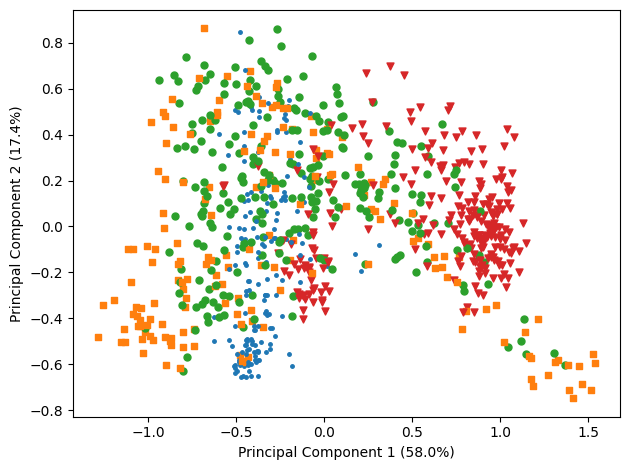

In [26]:
display_results_fuzzy_partition(X, keller_models, numeric_labels)

# Weighted FCM Wang 2004

In [11]:
%%capture
wang_models = np.array([])
for i in range(2):
    model = fcm_wang2004(X, c, w_beta=1.0, verbose=True)
    wang_models = np.append(wang_models, model)
wang_models = sorted(wang_models, key=lambda model: model['obj_func'])

J values: [0.3639773029390286, 0.3640103503685347]
ARI values: [0.0738418953355279, 0.07509035473349938]
NMI values: [0.09821588841988399, 0.09911526660458764]


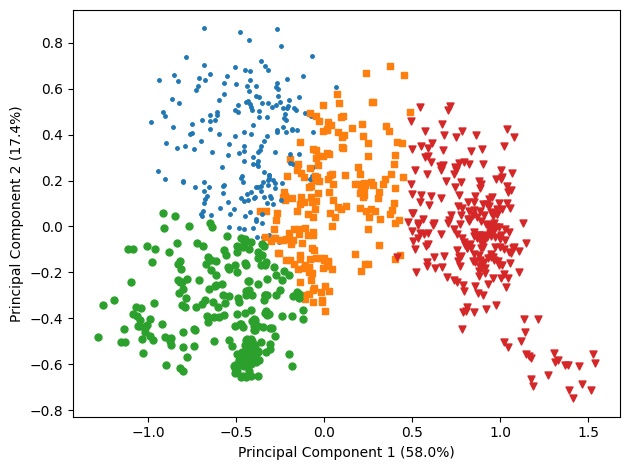

In [12]:
display_results_fuzzy_partition(X, wang_models, numeric_labels)

# SCAD1

In [27]:
%%capture
scad1_models = np.array([])
for i in range(5):
    model = scad1(X, c, verbose=True, K=2, epsilon=1e-6, init="None", stop_factor="Center")
    scad1_models = np.append(scad1_models, model)
scad1_models = sorted(scad1_models, key=lambda model: model['obj_func'])


J values: [17.582773561621053, nan, 22.206206444316184, nan, 19.707799143889083]
ARI values: [0.0854078930560495, 0.0, 0.09119310277765158, 0.0, 0.08561965079950698]
NMI values: [0.11339876294737342, 0.0, 0.11785658947038996, 0.0, 0.11789603409356714]


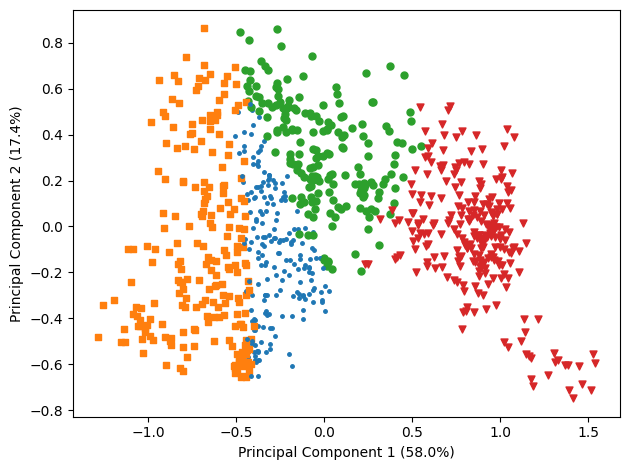

In [28]:
display_results_fuzzy_partition(X, scad1_models, numeric_labels)

# SCAD2

In [29]:
%%capture
scad2_models = np.array([])
for i in range(5):
    model = scad2(X, c, verbose=True, init="None", epsilon=1e-6, stop_factor="center")
    scad2_models = np.append(scad2_models, model)
scad2_models = sorted(scad2_models, key=lambda model: model['obj_func'])


J values: [0.17052574864285908, 0.17052648523869993, 0.17052649737690773, 0.1705265142598403, 0.1705265177837529]
ARI values: [0.13399693132028412, 0.13399693132028412, 0.13399693132028412, 0.13399693132028412, 0.13399693132028412]
NMI values: [0.1762417798484665, 0.1762417798484665, 0.17624177984846653, 0.17624177984846653, 0.17624177984846653]


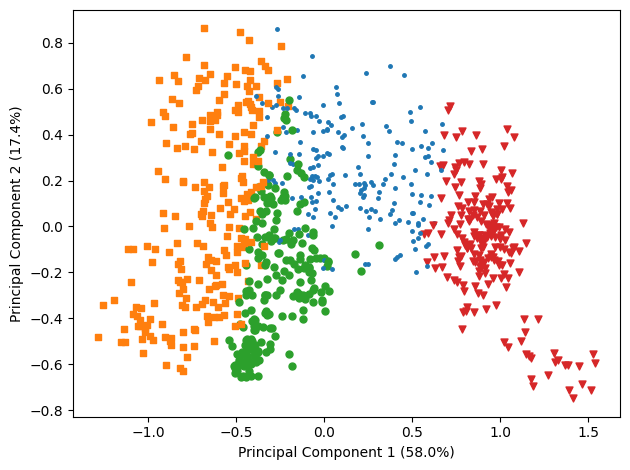

In [30]:
display_results_fuzzy_partition(X, scad2_models, numeric_labels)

# IFWFCM - Xing et al. 2014

In [31]:
%%capture
ifwfcm_models = np.array([])
for i in range(5):
    model = ifwfcm_xing2014(X, c, verbose=True, init="None")
    ifwfcm_models = np.append(ifwfcm_models, model)
ifwfcm_models = sorted(ifwfcm_models, key=lambda model: model['obj_func'])

J values: [0.2499274182778612, 0.24996294299920235, 0.25028604049599196, 0.25214526111374236, 0.25296581359625053]
ARI values: [0.07223992761190555, 0.06828319259119833, 0.06757337371349625, 0.06467810889761405, 0.06299945266990736]
NMI values: [0.08582356766257798, 0.07963895086769339, 0.0797778440218238, 0.093494510010748, 0.09364366065044241]


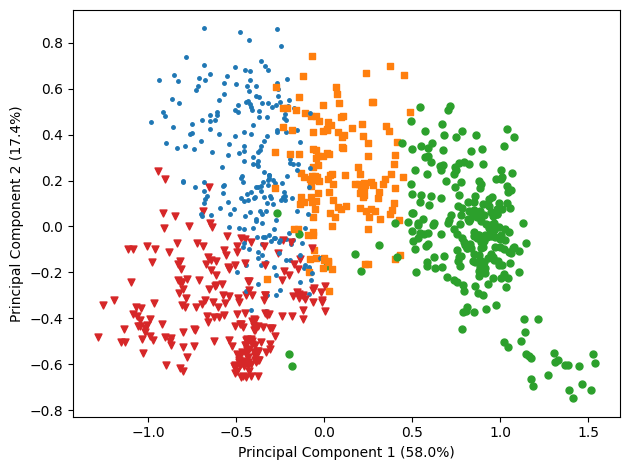

In [32]:
display_results_fuzzy_partition(X, ifwfcm_models, numeric_labels)

# IFWFCM_KD Xing 2014

In [33]:
%%capture
ifwfcm_kd_models = np.array([])
for i in range(5):
    model = ifwfcm_kd_xing2014(X, c, verbose=True, epsilon=1e-6, init="None")
    ifwfcm_kd_models = np.append(ifwfcm_kd_models, model)
ifwfcm_kd_models = sorted(ifwfcm_kd_models, key=lambda model: model['obj_func'])

J values: [4.632069780010702, 4.632073747415936, 4.632074058624253, 4.632076107414084, 4.63214727145469]
ARI values: [0.07739722676641592, 0.07739722676641592, 0.07739722676641592, 0.0784111051914149, 0.07935575188390276]
NMI values: [0.0904866236306665, 0.09048662363066648, 0.0904866236306665, 0.09148343959330052, 0.09240919199235136]


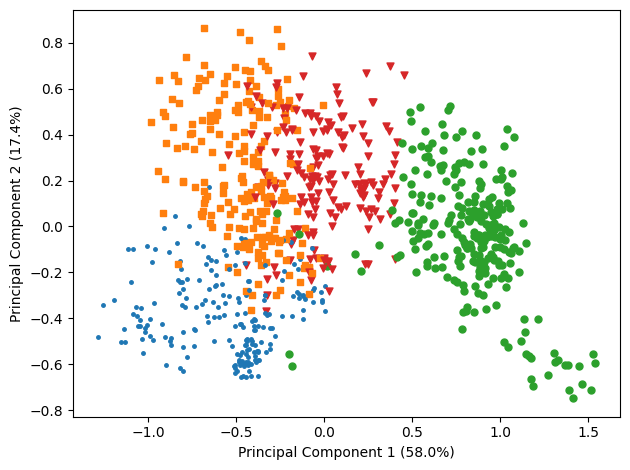

In [34]:
display_results_fuzzy_partition(X, ifwfcm_kd_models, numeric_labels)